In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import XXMinusYYGate
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator

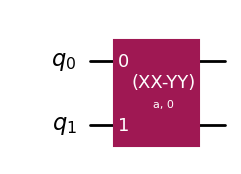

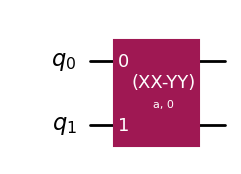

In [5]:
# Create a new circuit with two qubits
qc = QuantumCircuit(2)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
# gate = XXMinusYYGate(Parameter("a"), 0)
# qc.append(gate, [0,1])

# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

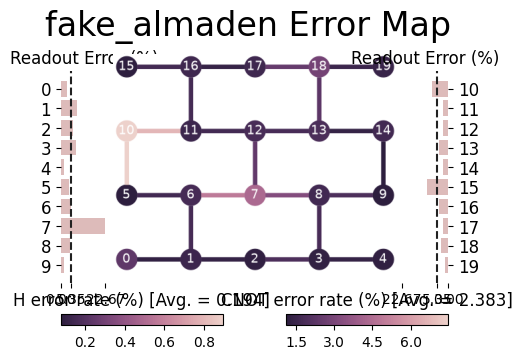

In [3]:
# Set up six different observables.

observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]# in format "q_1, q_0"
observables = [SparsePauliOp(label) for label in observables_labels]
observables += [SparsePauliOp(observables_labels, np.ones(len(observables_labels)))]

# Use the following code instead if you want to run on a simulator:

backend = FakeAlmadenV2()
local = True
fig = None
if local:
    from qiskit.visualization import plot_error_map
    fig = plot_error_map(backend, figsize=(5, 4))
fig

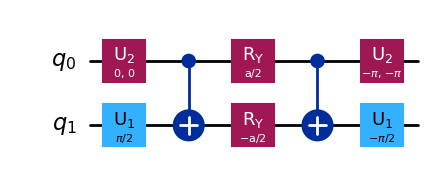

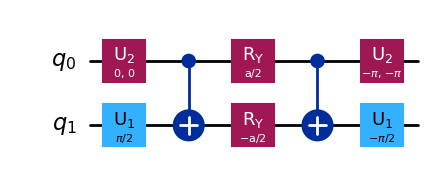

In [6]:
backend = AerSimulator()

# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
isa_circuit.draw("mpl")

In [5]:
from qiskit_ibm_runtime.options.utils import UnsetType
from qiskit_ibm_runtime import EstimatorOptions

# Run:
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
my_options = EstimatorOptions()
# Turn off all error mitigation and suppression
my_options.resilience_level = 0
my_options.default_shots = 420
my_options.default_precision = 0.3
my_options.seed_estimator = 42
my_options.simulator.seed_simulator = 42
print(my_options)
# my_options.options.environment.log_level = "DEBUG"
# QISKIT_IBM_RUNTIME_LOG_LEVEL = "DEBUG"
# QISKIT_IBM_RUNTIME_LOG_FILE = "LOGGER.txt"
estimator = Estimator(backend, options=my_options)

# from qiskit.primitives import StatevectorEstimator
# if isinstance(my_options.default_precision, UnsetType):
#     precision = 0.0
# else:
#     precision = my_options.default_precision
# if isinstance(my_options.simulator.seed_simulator, UnsetType):
#     seed = None
# else:
#     seed = my_options.simulator.seed_simulator
# estimator = StatevectorEstimator(default_precision=precision, seed=seed)
# mapped_observables = observables
# isa_circuit = qc



print(observables)
print(mapped_observables)

job = estimator.run([(isa_circuit, mapped_observables)])

EstimatorOptions(_VERSION=2, max_execution_time=Unset, environment=EnvironmentOptions(log_level='WARNING', callback=None, job_tags=None, private=False), simulator=SimulatorOptions(noise_model=Unset, seed_simulator=42, coupling_map=Unset, basis_gates=Unset), default_precision=0.3, default_shots=420, resilience_level=0, seed_estimator=42, dynamical_decoupling=DynamicalDecouplingOptions(enable=Unset, sequence_type=Unset, extra_slack_distribution=Unset, scheduling_method=Unset, skip_reset_qubits=Unset), resilience=ResilienceOptionsV2(measure_mitigation=Unset, measure_noise_learning=MeasureNoiseLearningOptions(num_randomizations=Unset, shots_per_randomization=Unset), zne_mitigation=Unset, zne=ZneOptions(amplifier=Unset, noise_factors=Unset, extrapolator=Unset, extrapolated_noise_factors=Unset), pec_mitigation=Unset, pec=PecOptions(max_overhead=Unset, noise_gain=Unset), layer_noise_learning=LayerNoiseLearningOptions(max_layers_to_learn=Unset, shots_per_randomization=Unset, num_randomizations

/home/nico/PycharmProjects/QC-MasterThesis/.venv/lib/python3.13/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:187: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")
/home/nico/PycharmProjects/QC-MasterThesis/.venv/lib/python3.13/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:269: UserWarning: Options {'seed_estimator': 42} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


In [6]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job.result()

PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(7,), dtype=float64>), stds=np.ndarray(<shape=(7,), dtype=float64>), shape=(7,)), metadata={'target_precision': 0.048795003647426664, 'shots': 420, 'circuit_metadata': {}})], metadata={'version': 2})

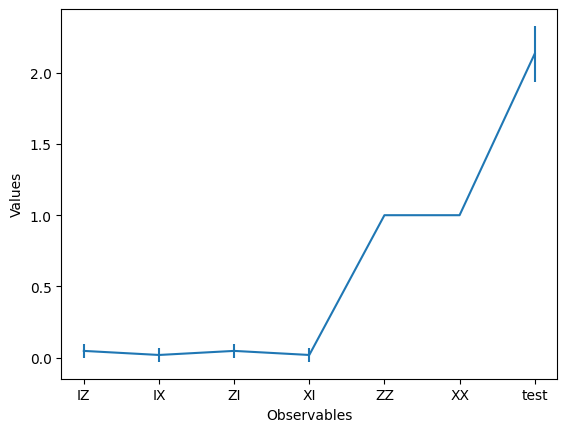

In [7]:
# This is the result from our single pub, which had six observables,
# so contains information on all six.

pub_result = job.result()[0]

# Plot the result

values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.errorbar(observables_labels+["test"], values, errors)
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

In [8]:
print(pub_result.data.shape)
values = pub_result.data["evs"]
print("Data:")
for key,value in pub_result.data.items():
    print(key, value, type(value), value.dtype==float)
print("MetaData:")
for key,value in pub_result.metadata.items():
    print(key, value, type(value)==int)

(7,)
Data:
evs [0.04761905 0.01904762 0.04761905 0.01904762 1.         1.
 2.13333333] <class 'numpy.ndarray'> True
stds [0.04873965 0.04878615 0.04873965 0.04878615 0.         0.
 0.1950516 ] <class 'numpy.ndarray'> True
MetaData:
target_precision 0.048795003647426664 False
shots 420 True
circuit_metadata {} False


In [9]:
from numbers import Complex
float == np.array(3,dtype=np.float64).dtype

True

In [10]:
np.issubdtype(int, np.integer)

True

In [11]:
pub_result.metadata

{'target_precision': 0.048795003647426664,
 'shots': 420,
 'circuit_metadata': {}}

In [12]:
job.result().metadata

{'version': 2}

In [13]:
import qiskit_ibm_runtime
import qiskit_aer
import qiskit

qiskit_ibm_runtime.version.get_version_info()

'0.40.1'

In [14]:
from dataclasses import asdict
asdict(estimator.options)

{'_VERSION': 2,
 'max_execution_time': Unset,
 'environment': {'log_level': 'WARNING',
  'callback': None,
  'job_tags': None,
  'private': False},
 'simulator': {'noise_model': Unset,
  'seed_simulator': 42,
  'coupling_map': Unset,
  'basis_gates': Unset},
 'default_precision': 0.3,
 'default_shots': 420,
 'resilience_level': 0,
 'seed_estimator': 42,
 'dynamical_decoupling': {'enable': Unset,
  'sequence_type': Unset,
  'extra_slack_distribution': Unset,
  'scheduling_method': Unset,
  'skip_reset_qubits': Unset},
 'resilience': {'measure_mitigation': Unset,
  'measure_noise_learning': {'num_randomizations': Unset,
   'shots_per_randomization': Unset},
  'zne_mitigation': Unset,
  'zne': {'amplifier': Unset,
   'noise_factors': Unset,
   'extrapolator': Unset,
   'extrapolated_noise_factors': Unset},
  'pec_mitigation': Unset,
  'pec': {'max_overhead': Unset, 'noise_gain': Unset},
  'layer_noise_learning': {'max_layers_to_learn': Unset,
   'shots_per_randomization': Unset,
   'num_r